# Saudi Stock Market (Tadawul) Analysis: Market Trends, Volatility, and Sector Insights

Author: Aryam Aljarallah
## Table of Contents

1. Project Overview
2. Dataset Source
3. Business Questions
4. Tools Used
5. Exploratory Data Analysis
6. Data Cleaning
7. Price Trend Analysis
8. Distribution & Outlier Analysis
9. Sector Analysis
10. Market Structure (Companies per Sector)
11. Company Price Analysis
12. Stock Movement Patterns
13. Market Performance & Volatility
14. Correlation Analysis
15. Key Findings
16. Skills Demonstrated
17. Conclusion

## Project Overview

This project explores stock market data from the Saudi Stock Exchange (Tadawul) using Python.  
The goal is to analyze company performance, price volatility, and trading activity to better understand market behavior.

## Dataset Source

The dataset used in this project contains historical stock market data from the Saudi Stock Exchange (Tadawul), including stock prices, trading volume, number of trades, and sector classification for multiple companies.

Source: Kaggle  
Dataset Link: https://www.kaggle.com/datasets/salwaalzahrani/saudi-stock-exchange-tadawul?resource=download&select=Tadawul_stcks_23_4.csv


## Business Questions

This analysis aims to answer several key questions about the Saudi stock market:

- How are companies distributed across different sectors in the Saudi stock market?
- Which sectors dominate trading activity in the market?
- Which companies achieved the highest gains and losses during the analyzed period?
- Which stocks show the highest price volatility?
- How does trading activity vary across the days of the trading week?
- What relationships exist between price variables and trading activity indicators?

## Tools Used The

analysis was performed using the following tools:
- Python
- Pandas for data manipulation
- NumPy for numerical operations
- Matplotlib and Seaborn for data visualization

## Import Libraries

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
plt.style.use("seaborn-v0_8-whitegrid")

plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 11

## Load Dataset

In [77]:
data = pd.read_csv("/content/Tadawul_stcks_23_4.csv")
data.head(10)

,symbol,name,trading_name,sectoer,date,open,high,low,close,change,perc_Change,volume_traded,value_traded,no_trades
0,2030,Saudi Arabia Refineries Co.,SARCO,Energy,2020-04-23,31.80,31.80,31.45,31.60,0.25,0.80,230790.0,7295880.55,507.0
1,2030,Saudi Arabia Refineries Co.,SARCO,Energy,2020-04-22,30.50,31.40,30.30,31.35,-0.35,-1.10,422695.0,13113020.10,1015.0
2,2030,Saudi Arabia Refineries Co.,SARCO,Energy,2020-04-21,31.70,32.30,31.30,31.70,-0.75,-2.31,266845.0,8497563.05,668.0
3,2030,Saudi Arabia Refineries Co.,SARCO,Energy,2020-04-20,32.70,32.90,32.10,32.45,-0.25,-0.76,254463.0,8271461.45,557.0
4,2030,Saudi Arabia Refineries Co.,SARCO,Energy,2020-04-19,32.50,32.80,32.45,32.70,0.50,1.55,199425.0,6500652.35,498.0
5,2030,Saudi Arabia Refineries Co.,SARCO,Energy,2020-04-16,33.05,33.05,32.10,32.20,-0.90,-2.72,295726.0,9572875.05,793.0
6,2030,Saudi Arabia Refineries Co.,SARCO,Energy,2020-04-15,33.80,33.80,32.90,33.10,-0.50,-1.49,330647.0,11011066.65,823.0
7,2030,Saudi Arabia Refineries Co.,SARCO,Energy,2020-04-14,34.20,34.50,33.10,33.60,-0.65,-1.90,570738.0,19219033.45,1107.0
8,2030,Saudi Arabia Refineries Co.,SARCO,Energy,2020-04-13,34.55,35.00,34.00,34.25,-0.10,-0.29,861290.0,29786404.85,1611.0
9,2030,Saudi Arabia Refineries Co.,SARCO,Energy,2020-04-12,34.10,34.50,34.00,34.35,0.40,1.18,800895.0,27445379.60,1823.0


## Exploratory Data Analysis (EDA)

In this section, we explore the dataset to understand its structure, data types, and basic statistics.  
We also check the distribution of companies and sectors, and identify any missing values.

In [78]:
data.shape

(6992, 14)

The dataset contains **6,992 rows and 14 columns**

In [79]:
data.columns

Index(['symbol', 'name', 'trading_name ', 'sectoer', 'date', 'open', 'high',
       'low', 'close', 'change', 'perc_Change', 'volume_traded ',
       'value_traded', 'no_trades '],
      dtype='object')

The dataset includes several important variables such as:

- **open, high, low, close**: stock price levels during the trading session  
- **volume_traded**: The volume of the trades for the day  
- **value_traded**: The value of the trades for the day  
- **no_trades**: number of executed trades  
- **sector**: company sector classification

In [80]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6992 entries, 0 to 6991
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   symbol          6992 non-null   int64  
 1   name            6992 non-null   object 
 2   trading_name    6992 non-null   object 
 3   sectoer         6992 non-null   object 
 4   date            6992 non-null   object 
 5   open            6830 non-null   float64
 6   high            6830 non-null   float64
 7   low             6830 non-null   float64
 8   close           6992 non-null   float64
 9   change          6992 non-null   float64
 10  perc_Change     6992 non-null   float64
 11  volume_traded   6992 non-null   float64
 12  value_traded    6992 non-null   float64
 13  no_trades       6992 non-null   float64
dtypes: float64(9), int64(1), object(4)
memory usage: 764.9+ KB


In [81]:
data.describe()

,symbol,open,high,low,close,change,perc_Change,volume_traded,value_traded,no_trades
count,6992.000000,6830.000000,6830.000000,6830.000000,6992.000000,6992.000000,6992.000000,6.992000e+03,6.992000e+03,6992.000000
mean,4113.914903,24.659725,25.182366,24.196105,24.328474,-0.089798,-0.336230,1.136108e+06,2.358603e+07,1076.635584
std,2257.109245,22.733866,23.249451,22.309276,22.576215,1.266593,3.683778,3.011323e+06,6.681986e+07,1648.871027
min,1010.000000,5.740000,5.950000,5.740000,5.390000,-14.000000,-12.880000,0.000000e+00,0.000000e+00,0.000000
25%,2200.000000,10.360000,10.580000,10.140000,10.220000,-0.340000,-1.850000,1.980355e+05,3.322344e+06,336.000000
50%,4040.000000,15.810000,16.120000,15.440000,15.500000,0.000000,0.000000,4.225855e+05,8.190636e+06,639.500000
75%,5110.000000,29.700000,30.300000,29.050000,29.060000,0.250000,1.480000,9.724018e+05,1.999385e+07,1193.000000
max,8312.000000,157.000000,163.000000,155.400000,158.800000,12.400000,19.930000,6.831751e+07,1.064690e+09,26201.000000


In [82]:
data.describe(include="object")

,name,trading_name,sectoer,date
count,6992,6992,6992,6992
unique,200,200,11,35
top,Saudi Arabia Refineries Co.,SARCO,Financials,2020-04-23
freq,35,35,1645,200


In [83]:
#The 5 most common trading_name in the dataset
data["trading_name "].value_counts().head()

,count
trading_name,
SARCO,35
SAUDI ARAMCO,35
PETRO RABIGH,35
BAHRI,35
ALDREES,35


In [84]:
#The 5 least common trading in the dataset
data["trading_name "].value_counts().tail()

,count
trading_name,
JABAL OMAR,35
ALMRAKEZ,35
KEC,35
ARAB SEA,34
SULAIMAN ALHABIB,28


In [85]:
#The 5 most common sectors in the dataset
data["sectoer"].value_counts().head()

,count
sectoer,
Financials,1645
Materials,1470
Real Estate,980
Consumer Discretionary,840
Industrials,700


In [86]:
#The 5 least common sectors in the dataset

data["sectoer"].value_counts().tail()

,count
sectoer,
Health Care,273
Communication Services,210
Energy,175
Utilities,70
Information Technology,69


In [87]:
data.isnull().sum()

,0
symbol,0
name,0
trading_name,0
sectoer,0
date,0
open,162
high,162
low,162
close,0
change,0


## Data Cleaning

### Handling Missing Values

We observed missing values in the following columns:

- open
- high
- low

Each column contained **162 missing values**.

In [88]:
data[data["open"].isnull()]

,symbol,name,trading_name,sectoer,date,open,high,low,close,change,perc_Change,volume_traded,value_traded,no_trades
634,2150,The National Company for Glass Industries,ZOUJAJ,Materials,2020-04-19,NaN,NaN,NaN,14.02,0.0,0.0,14260.0,200266.32,81.0
1750,1330,Abdullah A. M. Al-Khodari Sons Co.,ALKHODARI,Industrials,2020-04-23,NaN,NaN,NaN,5.39,0.0,0.0,0.0,0.00,0.0
1751,1330,Abdullah A. M. Al-Khodari Sons Co.,ALKHODARI,Industrials,2020-04-22,NaN,NaN,NaN,5.39,0.0,0.0,0.0,0.00,0.0
1752,1330,Abdullah A. M. Al-Khodari Sons Co.,ALKHODARI,Industrials,2020-04-21,NaN,NaN,NaN,5.39,0.0,0.0,0.0,0.00,0.0
1753,1330,Abdullah A. M. Al-Khodari Sons Co.,ALKHODARI,Industrials,2020-04-20,NaN,NaN,NaN,5.39,0.0,0.0,0.0,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6490,4345,Swicorp Wabel REIT Fund,SWICORP WABEL REIT,Real Estate,2020-03-23,NaN,NaN,NaN,7.20,0.0,0.0,8939.0,62384.46,60.0
6537,4347,Bonyan REIT Fund,BONYAN REIT,Real Estate,2020-04-23,NaN,NaN,NaN,8.00,0.0,0.0,8394.0,68153.33,114.0
6562,4347,Bonyan REIT Fund,BONYAN REIT,Real Estate,2020-03-19,NaN,NaN,NaN,8.67,0.0,0.0,8404.0,74721.10,56.0
6595,4348,Alkhabeer REIT Fund,ALKHABEER REIT,Real Estate,2020-03-23,NaN,NaN,NaN,10.86,0.0,0.0,2341.0,24808.38,23.0


We noticed that rows with missing values in **open** also had missing values in **high** and **low**.
This means the missing values occur in the same rows.

In [89]:
data[data["open"].isnull()].groupby(["sectoer"])["sectoer"].count()

,sectoer
sectoer,
Communication Services,35
Consumer Staples,39
Financials,36
Industrials,35
Information Technology,2
Materials,1
Real Estate,14


We checked whether the missing values belonged to a specific sector.
The results showed that they were distributed across multiple sectors.

In [90]:
data[data["open"].isnull()].groupby(["trading_name "])["trading_name "].count()

,trading_name
trading_name,
ALAHLI REIT 1,1
ALKHABEER REIT,2
ALKHODARI,35
ARAB SEA,2
ATHEEB TELECOM,35
BONYAN REIT,2
ENAYA,1
MASHAAR REIT,1
MULKIA REIT,4


The missing values were associated with the following companies:

- ALKHODARI
- ATHEEB TELECOM
- THIMAR
- WAFA INSURANCE

Each company appeared **35 times** in the dataset, and all their rows contained missing values.

Removing these rows would effectively remove these companies entirely from the dataset.

To preserve the dataset and avoid losing information about these companies, we decided to fill the missing values using the **mean of the column**.

In [91]:
data["open"] = data["open"].fillna(data["open"].mean())
data["high"] = data["high"].fillna(data["high"].mean())
data["low"] = data["low"].fillna(data["low"].mean())

In [92]:
data.isnull().sum()

,0
symbol,0
name,0
trading_name,0
sectoer,0
date,0
open,0
high,0
low,0
close,0
change,0


After filling the missing values, we verified that no null values remain in the dataset.

In [93]:
data.duplicated().sum()

np.int64(0)

We checked for duplicated rows in the dataset and confirmed that no duplicates exist.

In [94]:
data.columns

Index(['symbol', 'name', 'trading_name ', 'sectoer', 'date', 'open', 'high',
       'low', 'close', 'change', 'perc_Change', 'volume_traded ',
       'value_traded', 'no_trades '],
      dtype='object')

In [95]:
data = data.rename(columns={
    "sectoer":"sector",
    "trading_name ":"trading_name",
    "volume_traded ":"volume_traded",
    "no_trades ":"no_trades"
})

Some column names contained spelling mistakes or extra spaces.  
These were corrected to ensure consistency in the analysis.

In [96]:
data["date"] = pd.to_datetime(data["date"])

The **date** column was converted to datetime format to enable time-based analysis.

In [97]:
data["no_trades"] = data["no_trades"].astype("int")

The **no_trades** column was converted from float to integer since the number of trades should be a whole number.

## Price Trends Analysis

In this section, we analyze stock price trends using line plots.  
We first explore the overall behavior of closing prices across the dataset, then examine the relationship between opening and closing prices.  
Finally, we analyze a single company in detail.

### Closing Price Trend

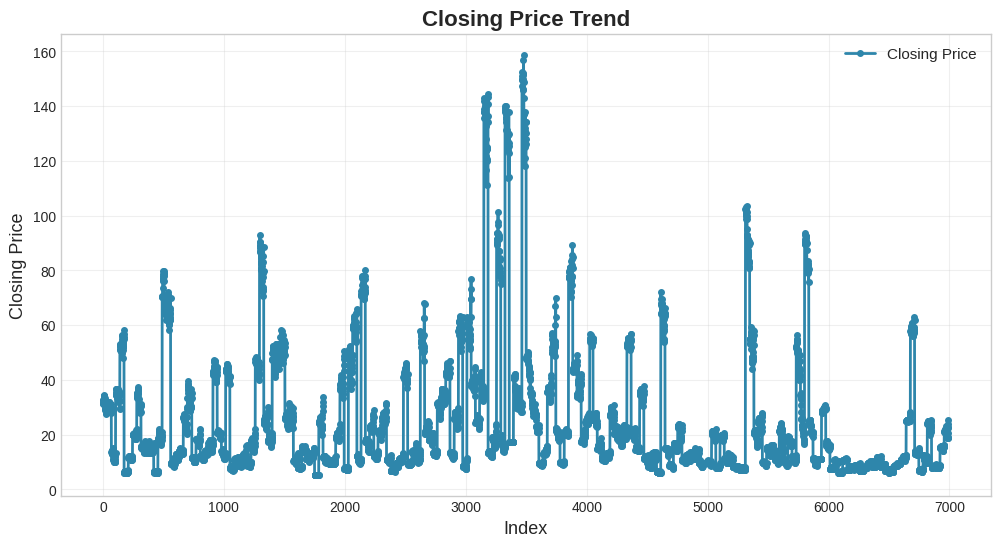

In [98]:
plt.figure()

plt.plot(
    data["close"],
    color="#2E86AB",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Closing Price"
)

plt.title("Closing Price Trend", fontweight="bold")
plt.xlabel("Index")
plt.ylabel("Closing Price")

plt.legend()
plt.grid(alpha=0.3)


The plot shows the general trend of closing prices across the dataset.  
It provides an initial overview of how stock prices fluctuate over time.

### Opening vs Closing Price

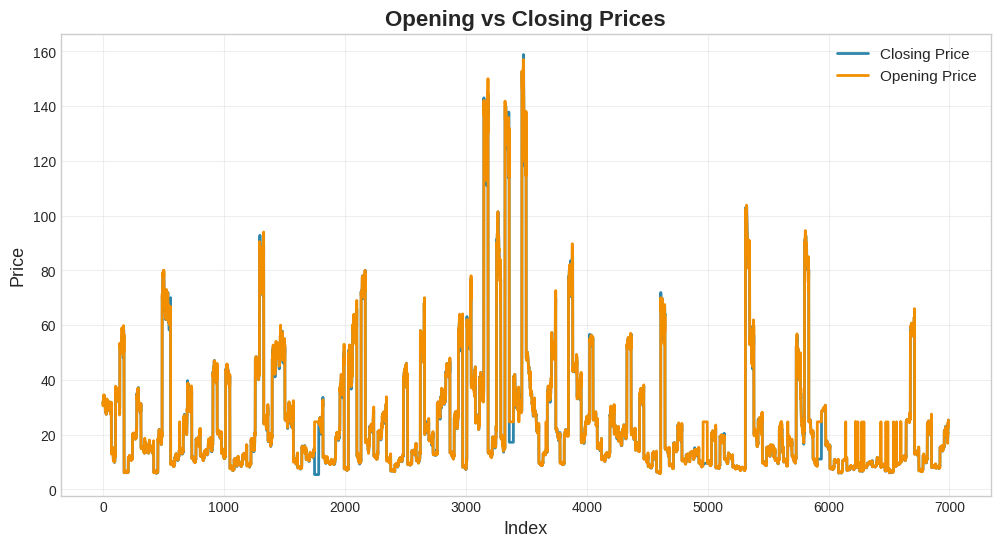

In [99]:
plt.figure()

plt.plot(data["close"], color="#2E86AB", linewidth=2, label="Closing Price")
plt.plot(data["open"], color="#F18F01", linewidth=2, label="Opening Price")

plt.title("Opening vs Closing Prices", fontweight="bold")
plt.xlabel("Index")
plt.ylabel("Price")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

This visualization compares opening and closing prices across the dataset, helping us observe how prices change during trading sessions.

### Case Study: SARCO

In [100]:
data_sarco = data[data['trading_name'] == "SARCO"]
data_sarco

,symbol,name,trading_name,sector,date,open,high,low,close,change,perc_Change,volume_traded,value_traded,no_trades
0,2030,Saudi Arabia Refineries Co.,SARCO,Energy,2020-04-23,31.80,31.80,31.45,31.60,0.25,0.80,230790.0,7295880.55,507
1,2030,Saudi Arabia Refineries Co.,SARCO,Energy,2020-04-22,30.50,31.40,30.30,31.35,-0.35,-1.10,422695.0,13113020.10,1015
2,2030,Saudi Arabia Refineries Co.,SARCO,Energy,2020-04-21,31.70,32.30,31.30,31.70,-0.75,-2.31,266845.0,8497563.05,668
3,2030,Saudi Arabia Refineries Co.,SARCO,Energy,2020-04-20,32.70,32.90,32.10,32.45,-0.25,-0.76,254463.0,8271461.45,557
4,2030,Saudi Arabia Refineries Co.,SARCO,Energy,2020-04-19,32.50,32.80,32.45,32.70,0.50,1.55,199425.0,6500652.35,498
5,2030,Saudi Arabia Refineries Co.,SARCO,Energy,2020-04-16,33.05,33.05,32.10,32.20,-0.90,-2.72,295726.0,9572875.05,793
6,2030,Saudi Arabia Refineries Co.,SARCO,Energy,2020-04-15,33.80,33.80,32.90,33.10,-0.50,-1.49,330647.0,11011066.65,823
7,2030,Saudi Arabia Refineries Co.,SARCO,Energy,2020-04-14,34.20,34.50,33.10,33.60,-0.65,-1.90,570738.0,19219033.45,1107
8,2030,Saudi Arabia Refineries Co.,SARCO,Energy,2020-04-13,34.55,35.00,34.00,34.25,-0.10,-0.29,861290.0,29786404.85,1611
9,2030,Saudi Arabia Refineries Co.,SARCO,Energy,2020-04-12,34.10,34.50,34.00,34.35,0.40,1.18,800895.0,27445379.60,1823


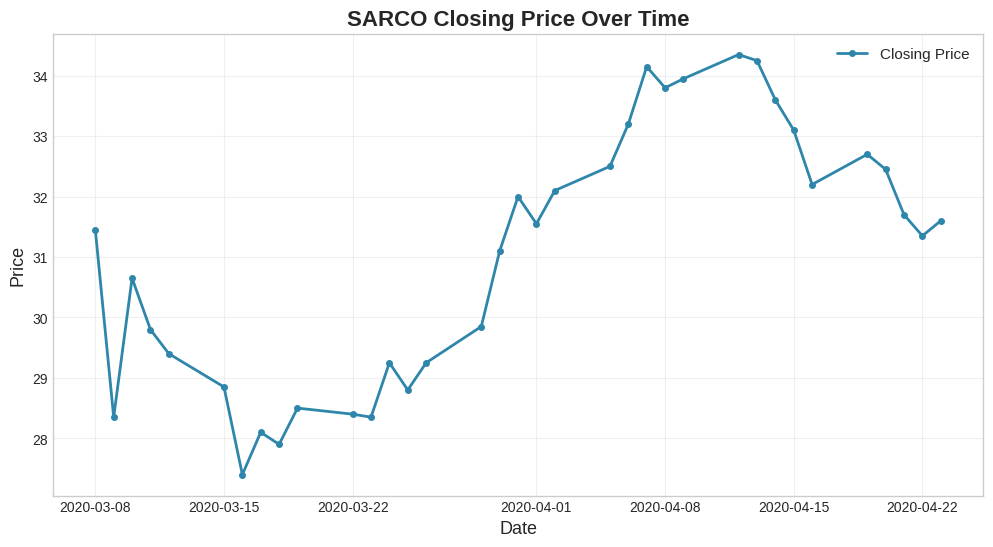

In [101]:
plt.figure()

plt.plot(
    data_sarco["date"],
    data_sarco["close"],
    color="#2E86AB",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Closing Price"
)

plt.title("SARCO Closing Price Over Time", fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

This chart shows how SARCO's closing price evolves over time.

### Price Components for SARCO

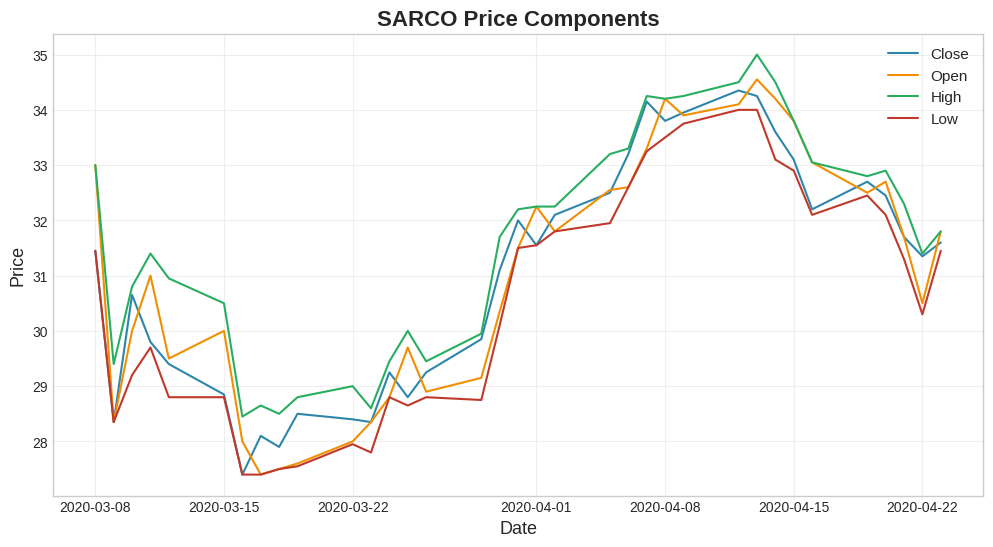

In [102]:
plt.figure()

plt.plot(data_sarco["date"], data_sarco["close"], color="#2E86AB", label="Close")
plt.plot(data_sarco["date"], data_sarco["open"], color="#F18F01", label="Open")
plt.plot(data_sarco["date"], data_sarco["high"], color="#27AE60", label="High")
plt.plot(data_sarco["date"], data_sarco["low"], color="#C0392B", label="Low")

plt.title("SARCO Price Components", fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

This visualization shows the relationship between opening, closing, high, and low prices for SARCO.
It provides a clearer view of the daily price range and market fluctuations.

We observe that the **high price consistently forms the upper boundary**, while the **low price forms the lower boundary** of the price range.
The **opening and closing prices typically lie between these two values**, which reflects the natural trading behavior during the market session.

### Distribution of Price Changes Outlier Analysis

To better understand how stock prices change, we visualize the distribution of the **change** column using a histogram.

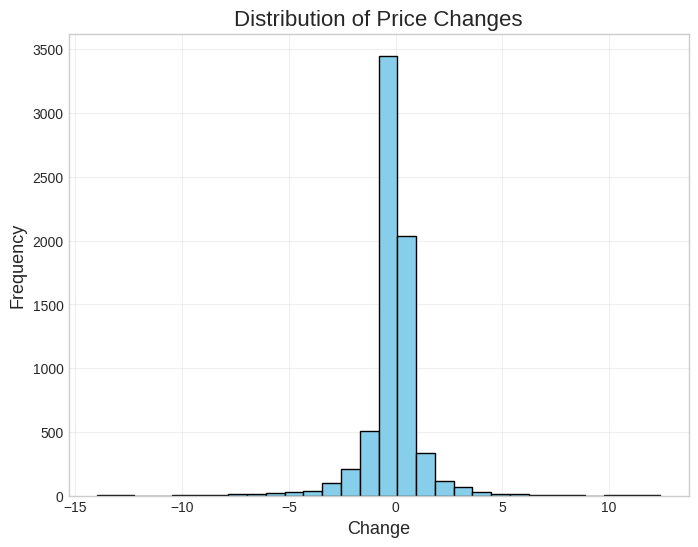

In [103]:
plt.figure(figsize=(8,6))

plt.hist(data['change'], bins=30, color='skyblue', edgecolor='black')

plt.title('Distribution of Price Changes')
plt.xlabel('Change')
plt.ylabel('Frequency')

plt.grid(alpha=0.3)

plt.show()

### Insight

The histogram shows that most price changes fall between **-5 and +5**.  
However, a few extreme values appear around **+10 and -10**, indicating the presence of outliers.

To investigate these extreme values, we filtered rows where the price change exceeded 10.

In [104]:
data[data["change"] > 10]

,symbol,name,trading_name,sector,date,open,high,low,close,change,perc_Change,volume_traded,value_traded,no_trades
3352,4061,Anaam International Holding Group,ANAAM HOLDING,Consumer Staples,2020-03-17,115.8,125.0,115.0,125.0,11.2,9.84,120805.0,14821731.2,689
3356,4061,Anaam International Holding Group,ANAAM HOLDING,Consumer Staples,2020-03-11,130.0,137.8,125.4,137.8,12.4,9.89,403755.0,53721146.4,2151
3357,4061,Anaam International Holding Group,ANAAM HOLDING,Consumer Staples,2020-03-10,120.0,125.4,114.0,125.4,11.4,10.00,96565.0,11708831.0,778


The outliers were mainly associated with a single company:

**ANAAM HOLDING**

This indicates that the large price movements were not errors but rather significant market movements for this company during that period.

In [105]:
data[data["change"] < -10]

,symbol,name,trading_name,sector,date,open,high,low,close,change,perc_Change,volume_traded,value_traded,no_trades
3358,4061,Anaam International Holding Group,ANAAM HOLDING,Consumer Staples,2020-03-09,114.0,117.4,114.0,114.0,-12.6,-9.95,54770.0,6265605.0,554
3359,4061,Anaam International Holding Group,ANAAM HOLDING,Consumer Staples,2020-03-08,132.0,136.0,126.6,126.6,-14.0,-9.96,84405.0,10798371.6,875
3499,2270,Saudia Dairy and Foodstuff Co.,SADAFCO,Consumer Staples,2020-03-08,138.0,138.0,126.0,126.0,-13.0,-9.35,19549.0,2565685.4,317


To better visualize the general distribution of price changes, we removed extreme values outside the range **[-5, 5]**.

In [106]:
data_filtered = data[(data["change"] < 5) & (data["change"] > -5)]

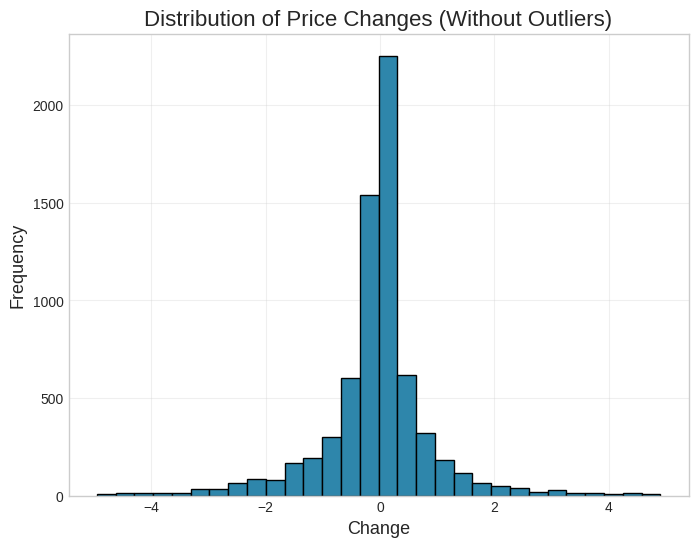

In [107]:
plt.figure(figsize=(8,6))

plt.hist(data_filtered['change'], bins=30, color='#2E86AB', edgecolor='black')

plt.title('Distribution of Price Changes (Without Outliers)')
plt.xlabel('Change')
plt.ylabel('Frequency')

plt.grid(alpha=0.3)

plt.show()

After removing outliers, the distribution becomes clearer.  
Most price changes are concentrated around **0**, indicating that daily stock price movements are generally small.

### Distribution of Percentage Price Change

To understand the behavior of percentage price movements, we visualize the distribution of the **perc_Change** column using a histogram.

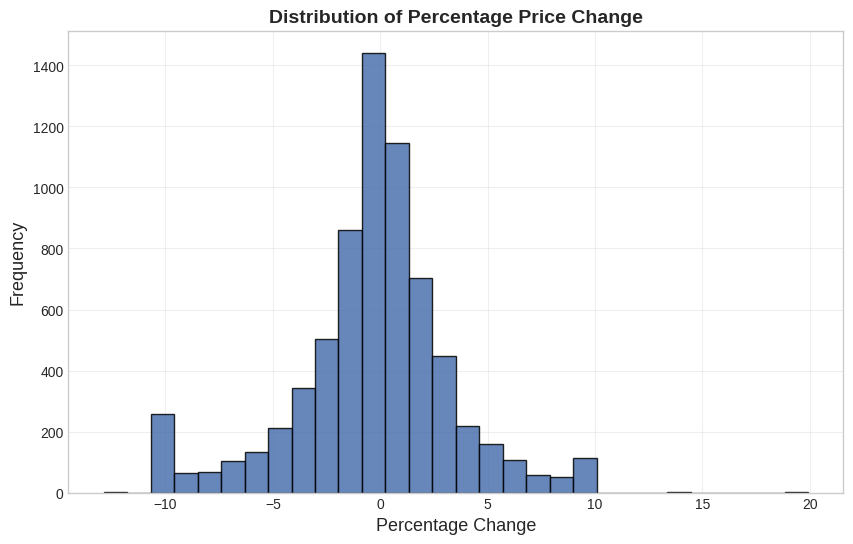

In [108]:
plt.figure(figsize=(10,6))

plt.hist(
    data['perc_Change'],
    bins=30,
    color="#4C72B0",
    edgecolor="black",
    alpha=0.85
)

plt.title("Distribution of Percentage Price Change", fontsize=14, fontweight="bold")
plt.xlabel("Percentage Change")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

### Insight

The histogram shows that most percentage price changes fall between **-10% and +10%**.  
However, a small number of extreme values appear outside this range, indicating the presence of outliers.

In [109]:
data_filtered = data[(data['perc_Change'] < 10) & (data['perc_Change'] > -10)]

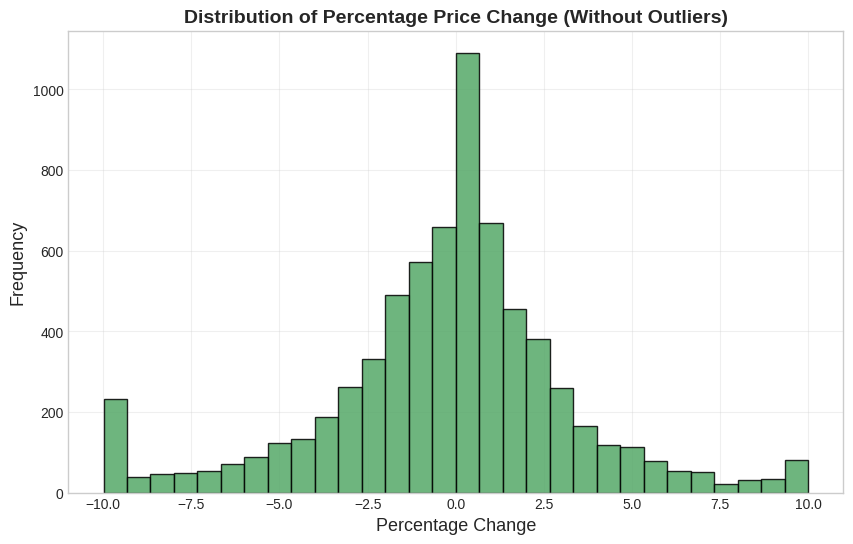

In [110]:
plt.figure(figsize=(10,6))

plt.hist(
    data_filtered['perc_Change'],
    bins=30,
    color="#55A868",
    edgecolor="black",
    alpha=0.85
)

plt.title("Distribution of Percentage Price Change (Without Outliers)", fontsize=14, fontweight="bold")
plt.xlabel("Percentage Change")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

After removing the outliers, the distribution becomes clearer.  
Most daily percentage changes are concentrated around **0%**, indicating that stock prices typically experience relatively small daily fluctuations.

### Insight

Most percentage price changes are concentrated around **0%**, indicating that daily stock price movements are generally small.

Large positive or negative changes occur less frequently and appear as outliers in the distribution.

### Box Plot Analysis for Price Changes

To better detect extreme values in the **change** column, we use a box plot.
Box plots are useful for identifying outliers and understanding the distribution of the data.

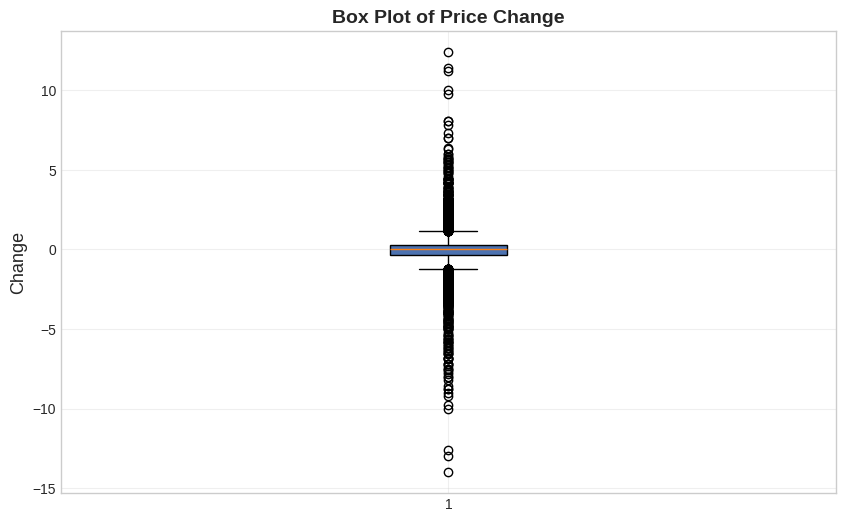

In [111]:
plt.figure(figsize=(10,6))

plt.boxplot(
    data['change'],
    patch_artist=True,
    boxprops=dict(facecolor="#4C72B0")
)

plt.title("Box Plot of Price Change", fontsize=14, fontweight="bold")
plt.ylabel("Change")

plt.grid(alpha=0.3)

plt.show()

The box plot reveals a large number of outliers in the **change** column.  
Most values are concentrated around **0**, while several extreme values appear far from the central distribution.

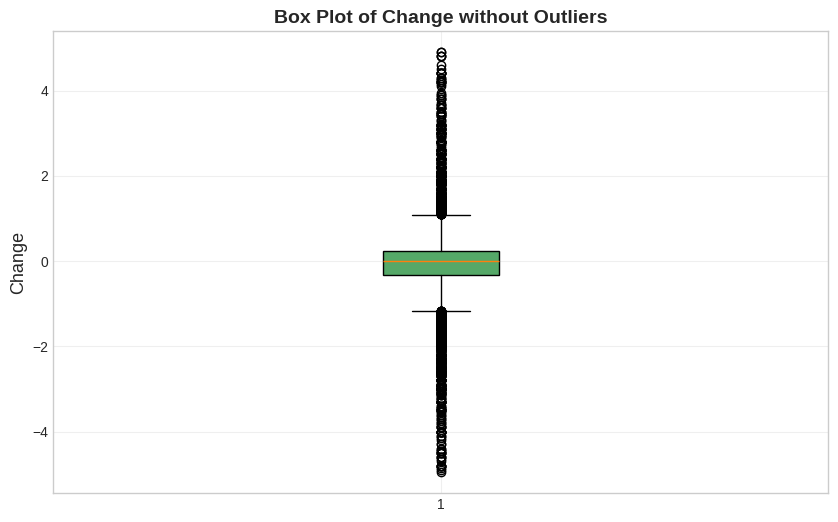

In [112]:
data_filtered = data[(data['change'] < 5) & (data['change'] > -5)]
plt.figure(figsize=(10,6))

plt.boxplot(
    data_filtered['change'],
    patch_artist=True,
    boxprops=dict(facecolor="#55A868")
)

plt.title("Box Plot of Change without Outliers", fontsize=14, fontweight="bold")
plt.ylabel("Change")

plt.grid(alpha=0.3)

plt.show()

After removing extreme outliers, the distribution becomes much clearer.  
Most daily price changes fall within a relatively narrow range around **0**, indicating that stock price movements are typically small.

In [113]:
data["change"].value_counts().head()

,count
change,
0.00,401
0.10,160
-0.10,155
0.20,127
0.04,120


The most frequent values in the **change** column are very close to zero, such as 0.00, 0.10, and -0.10.  
This indicates that most daily stock price movements are relatively small, with only minor changes occurring during trading sessions.

### Box Plot Analysis for Percentage Change

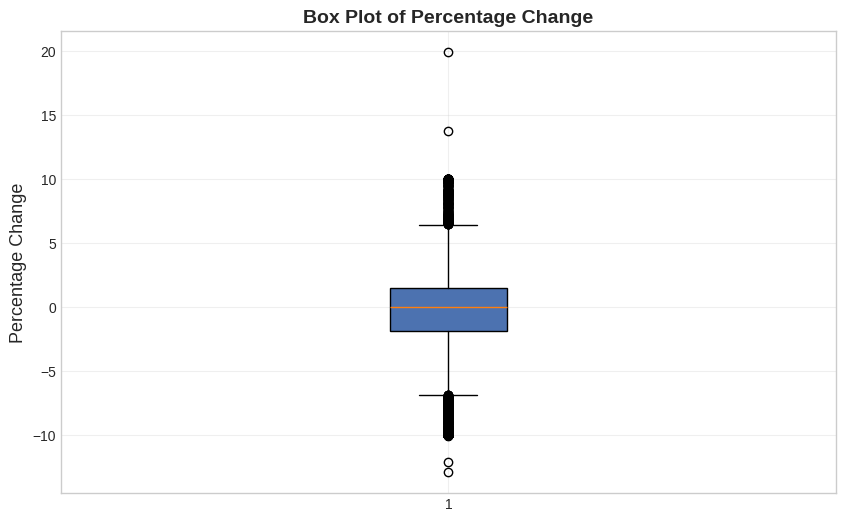

In [114]:
plt.figure(figsize=(10,6))

plt.boxplot(
    data['perc_Change'],
    patch_artist=True,
    boxprops=dict(facecolor="#4C72B0")
)

plt.title("Box Plot of Percentage Change", fontsize=14, fontweight="bold")
plt.ylabel("Percentage Change")

plt.grid(alpha=0.3)

plt.show()

The box plot shows that most percentage price changes are concentrated around **0%**, indicating that daily stock movements are generally small.

However, several extreme values appear outside the main distribution, reaching values above **10%** and below **-10%**, which indicates the presence of significant outliers in the dataset.

These extreme values represent unusually large market movements that occur less frequently compared to typical daily price fluctuations.

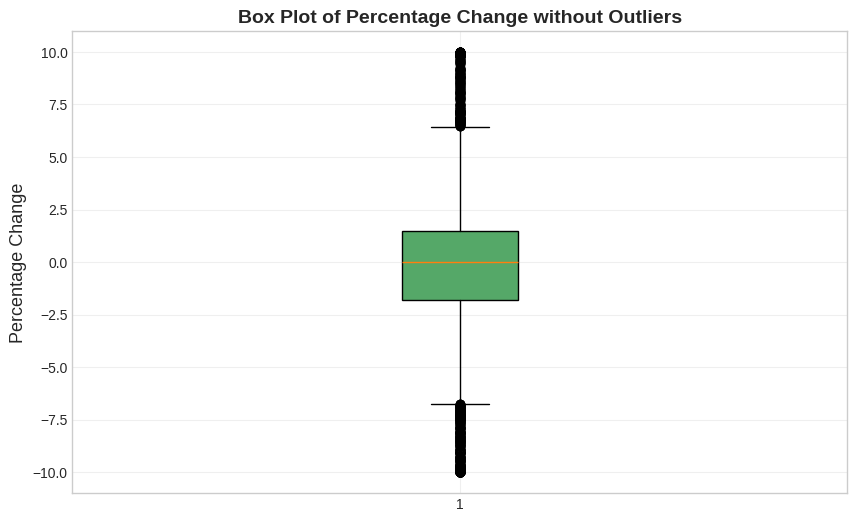

In [115]:
data_filtered = data[(data['perc_Change'] < 10) & (data['perc_Change'] > -10)]

plt.figure(figsize=(10,6))

plt.boxplot(
    data_filtered['perc_Change'],
    patch_artist=True,
    boxprops=dict(facecolor="#55A868")
)

plt.title("Box Plot of Percentage Change without Outliers", fontsize=14, fontweight="bold")
plt.ylabel("Percentage Change")

plt.grid(alpha=0.3)

plt.show()

After removing extreme outliers, the distribution becomes more compact and easier to interpret.
Most percentage price changes remain concentrated around **0%**, confirming that daily market movements are typically small.

The median value is close to zero, indicating that price increases and decreases occur with similar frequency.

## Sector Analysis

In this section, we analyze the performance and activity of different sectors in the market.

The analysis focuses on:
- Average closing price by sector
- Number of trades in each sector
- Total trading value across sectors

### Average Closing Price by Sector

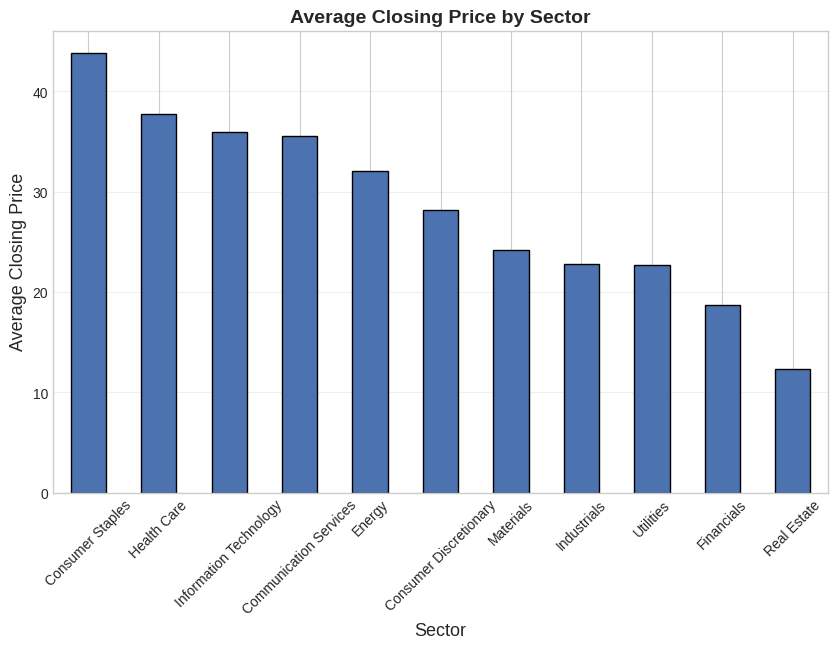

In [116]:
plt.figure(figsize=(10,6))

grouped_data = data.groupby("sector")["close"].mean().sort_values(ascending=False)

grouped_data.plot.bar(
    color="#4C72B0",
    edgecolor="black"
)

plt.title("Average Closing Price by Sector", fontsize=14, fontweight="bold")
plt.xlabel("Sector")
plt.ylabel("Average Closing Price")

plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)

plt.show()

### Insight

The bar chart shows the average closing price across different sectors.

Consumer Staples has the highest average closing price, followed by Health Care and Information Technology.
On the other hand, Real Estate and Financials show lower average closing prices compared to other sectors.

This indicates that stocks in the Consumer Staples sector tend to trade at higher price levels.

### Trading Activity by Sector

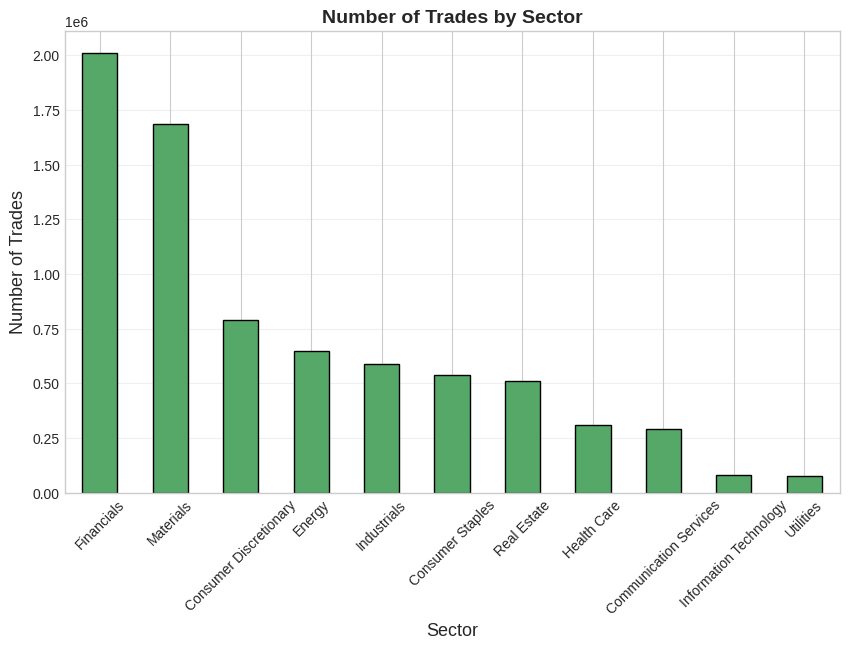

In [117]:
plt.figure(figsize=(10,6))

grouped_data = data.groupby("sector")["no_trades"].sum().sort_values(ascending=False)

grouped_data.plot.bar(
    color="#55A868",
    edgecolor="black"
)

plt.title("Number of Trades by Sector", fontsize=14, fontweight="bold")
plt.xlabel("Sector")
plt.ylabel("Number of Trades")

plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)

plt.show()

### Insight

The Financials sector has the highest number of trades, indicating strong market activity and investor interest.

Materials and Consumer Discretionary also show relatively high trading activity, while sectors like Utilities and Information Technology have lower trading frequency.

### Total Trading Value by Sector

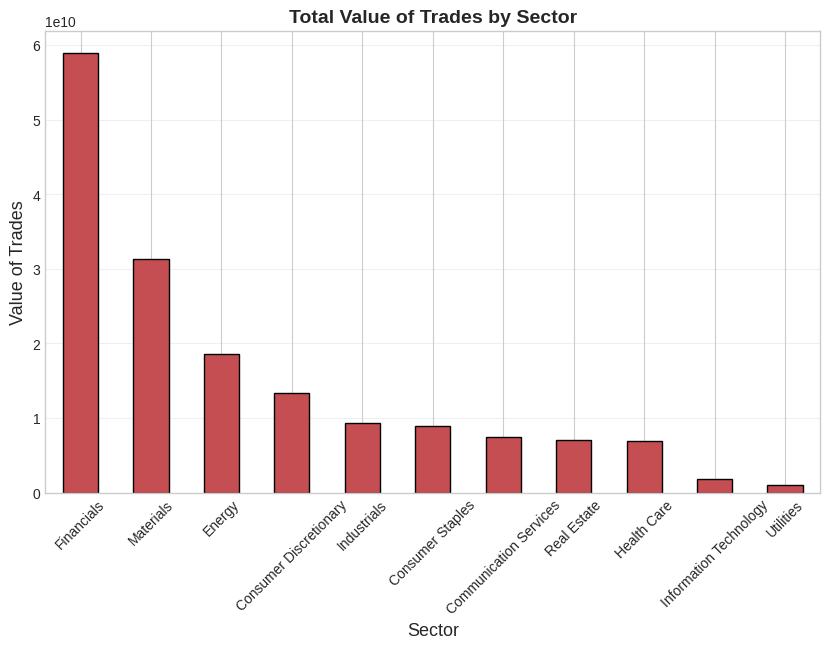

In [118]:
plt.figure(figsize=(10,6))

grouped_data = data.groupby("sector")["value_traded"].sum().sort_values(ascending=False)

grouped_data.plot.bar(
    color="#C44E52",
    edgecolor="black"
)

plt.title("Total Value of Trades by Sector", fontsize=14, fontweight="bold")
plt.xlabel("Sector")
plt.ylabel("Value of Trades")

plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)

plt.show()

### Insight

The Financials sector dominates the market in terms of total traded value, suggesting that it attracts significant investment capital.

Materials and Energy also show relatively high trading value, while sectors like Utilities and Information Technology have much lower traded values.

The Financials sector not only has the highest number of trades but also the highest total trading value, indicating both high activity and strong liquidity in this sector.

### Market Structure: Number of Companies per Sector


Understanding the number of companies in each sector helps explain market concentration and sector dominance.

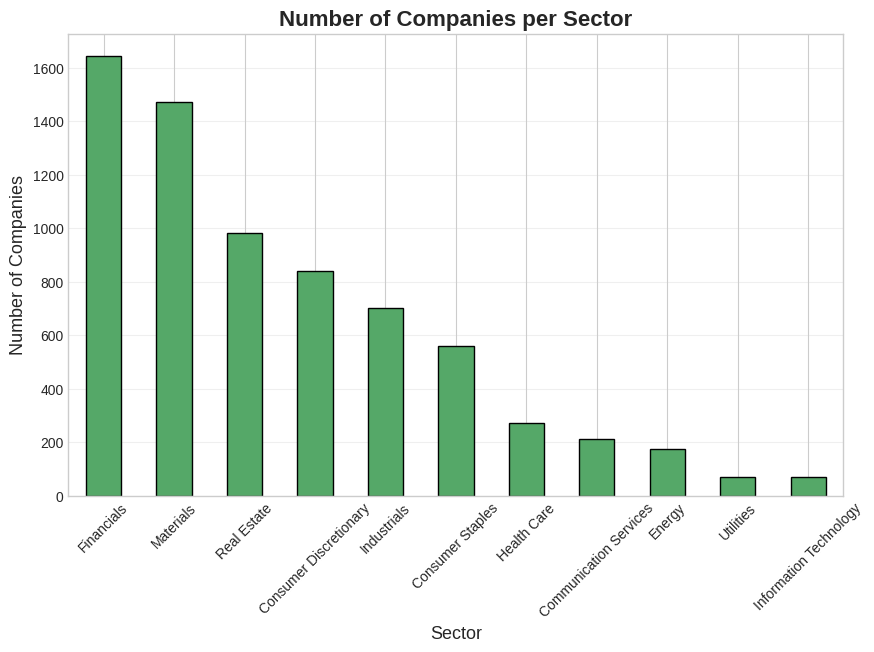

In [130]:
plt.figure(figsize=(10,6))

data["sector"].value_counts().plot.bar(
    color="#55A868",
    edgecolor="black"
)

plt.title("Number of Companies per Sector", fontweight="bold")
plt.xlabel("Sector")
plt.ylabel("Number of Companies")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

### Insight
####
The chart shows how companies are distributed across different sectors in the Saudi stock market.

The Financials and Materials sectors contain the largest number of companies, indicating strong representation and market presence in these industries.

On the other hand, sectors such as Utilities and Information Technology include significantly fewer companies, suggesting a smaller sector footprint within the market.

This distribution helps explain why some sectors show higher trading activity, as sectors with more companies naturally generate more market transactions.

## Company Price Analysis

In this section, we analyze companies based on their average closing price.

The goal is to identify:
- Companies with the highest average stock prices
- Companies with the lowest average stock prices

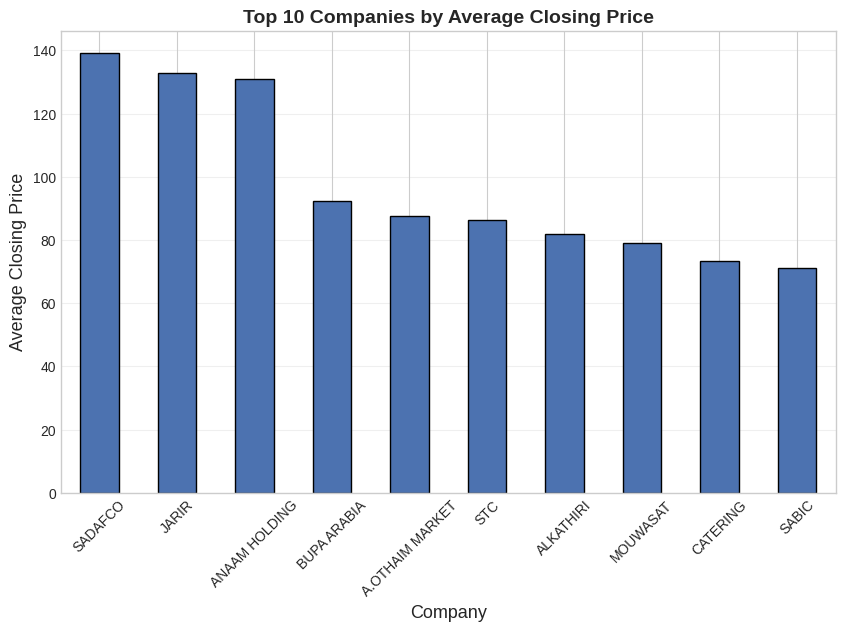

In [119]:
plt.figure(figsize=(10,6))

top_companies = data.groupby("trading_name")["close"].mean().sort_values(ascending=False).head(10)

top_companies.plot.bar(
    color="#4C72B0",
    edgecolor="black"
)

plt.title("Top 10 Companies by Average Closing Price", fontsize=14, fontweight="bold")
plt.xlabel("Company")
plt.ylabel("Average Closing Price")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

### Insight

The chart highlights the companies with the highest average closing prices.

SADAFCO appears to have the highest average stock price, followed by companies such as JARIR and ANAAM HOLDING.

This indicates that these companies generally trade at higher price levels compared to other firms in the market.

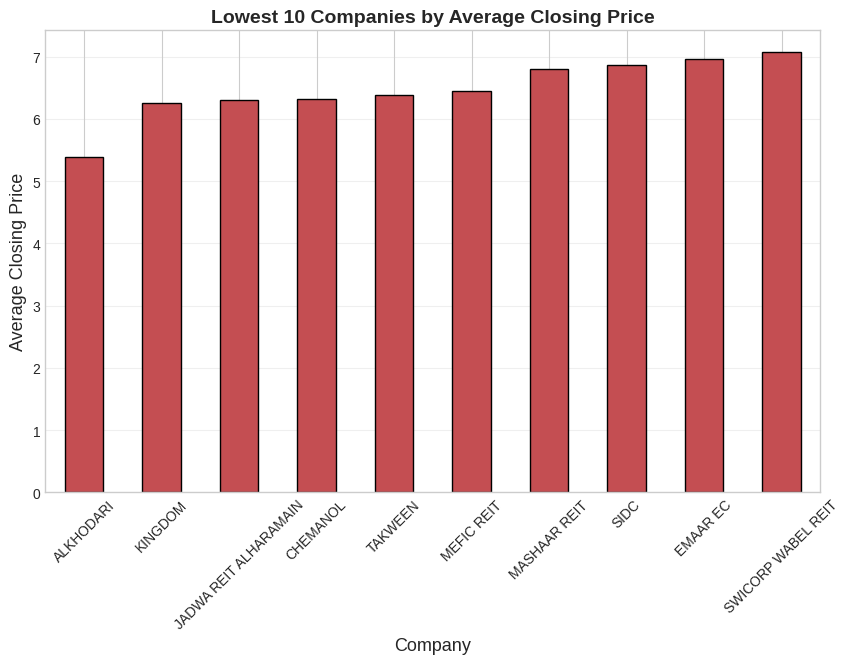

In [120]:
plt.figure(figsize=(10,6))

low_companies = data.groupby("trading_name")["close"].mean().sort_values(ascending=True).head(10)

low_companies.plot.bar(
    color="#C44E52",
    edgecolor="black"
)

plt.title("Lowest 10 Companies by Average Closing Price", fontsize=14, fontweight="bold")
plt.xlabel("Company")
plt.ylabel("Average Closing Price")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

### Insight

The chart shows the companies with the lowest average closing prices.

Companies such as ALKHODARI and KINGDOM have relatively low average stock prices compared to the rest of the market.

Lower stock prices do not necessarily indicate poor performance, but they may reflect company size, market perception, or sector characteristics.

The large difference between the highest and lowest average stock prices highlights the diversity in price levels across companies in the Saudi stock market.

## Stock Movement Patterns

In this section, we analyze stock movement patterns to understand which companies experience the highest average percentage change and how sectors behave during trading sessions.

Specifically, we examine:
- Companies with the highest average percentage change
- Sectors where prices often start high and close lower
- Companies where prices often start low and close higher

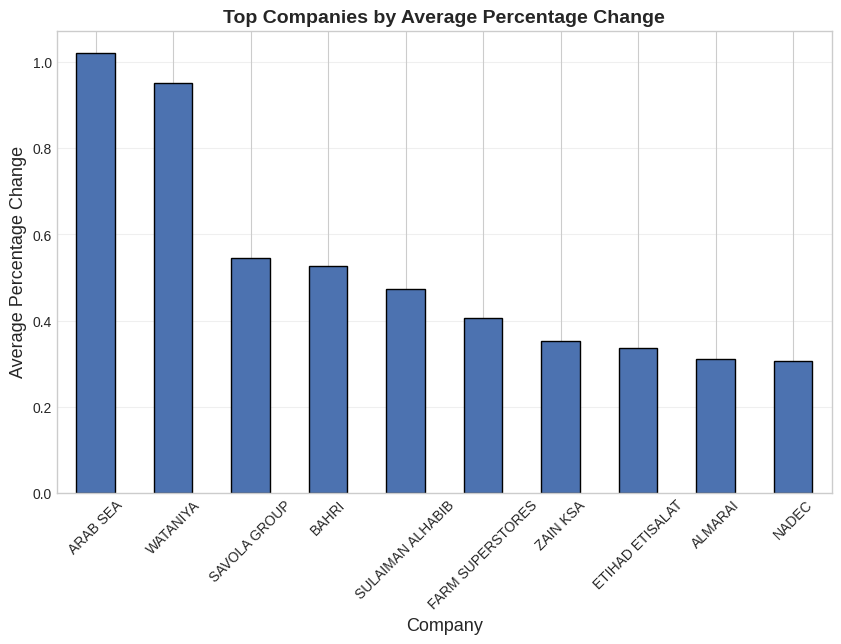

In [121]:
plt.figure(figsize=(10,6))

top_change = data.groupby("trading_name")["perc_Change"].mean().sort_values(ascending=False).head(10)

top_change.plot.bar(
    color="#4C72B0",
    edgecolor="black"
)

plt.title("Top Companies by Average Percentage Change", fontsize=14, fontweight="bold")
plt.xlabel("Company")
plt.ylabel("Average Percentage Change")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

### Insight

The chart highlights companies with the highest average percentage price changes.

Arab Sea and Wataniya appear to experience the largest average percentage movements, suggesting higher volatility compared to other companies.

Higher percentage changes may indicate stronger market reactions or increased trading activity.

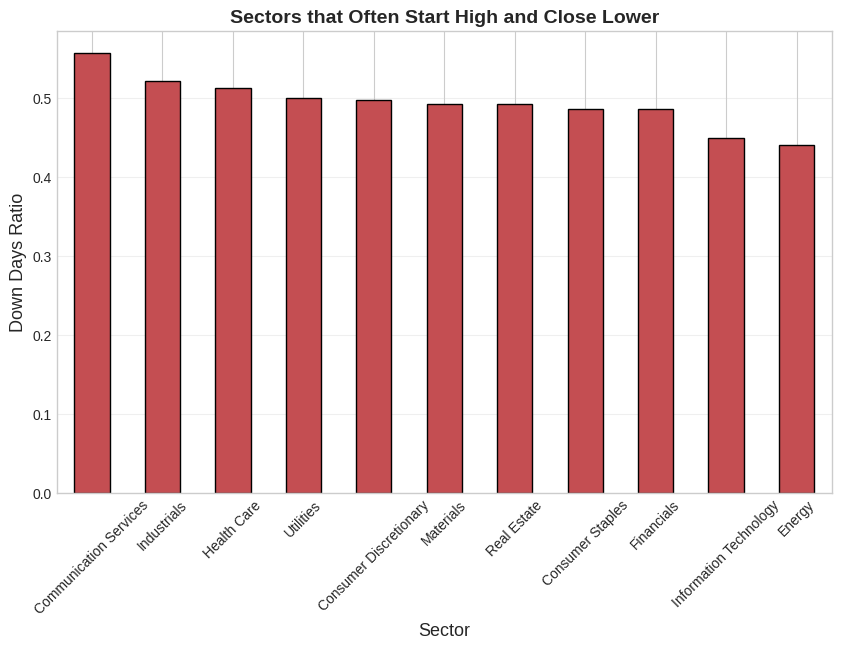

In [122]:
data["down"] = data["open"] > data["close"]

sector_down = data.groupby("sector")["down"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))

sector_down.plot.bar(
    color="#C44E52",
    edgecolor="black"
)

plt.title("Sectors that Often Start High and Close Lower", fontsize=14, fontweight="bold")
plt.xlabel("Sector")
plt.ylabel("Down Days Ratio")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

### Insight

The chart shows sectors where stock prices frequently open higher but close lower.

Communication Services and Industrials show relatively higher ratios of such movements, suggesting that prices in these sectors may experience intraday declines after strong openings.

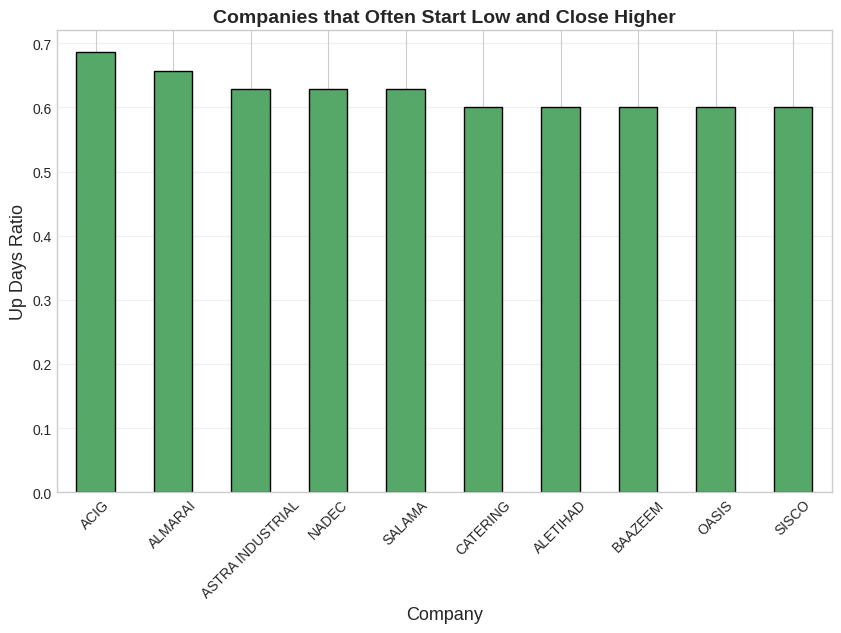

In [123]:
data["up"] = data["open"] < data["close"]

company_up = data.groupby("trading_name")["up"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

company_up.plot.bar(
    color="#55A868",
    edgecolor="black"
)

plt.title("Companies that Often Start Low and Close Higher", fontsize=14, fontweight="bold")
plt.xlabel("Company")
plt.ylabel("Up Days Ratio")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.show()

### Insight

The chart highlights companies where stock prices frequently open lower but close higher during the trading session.

Companies such as ACIG and Almarai show higher ratios of upward movements, indicating stronger intraday recovery patterns.

## Market Performance & Volatility Analysis

In this section, we examine market performance by identifying the top gaining and losing companies, analyzing stock volatility, and exploring trading activity across days of the week.

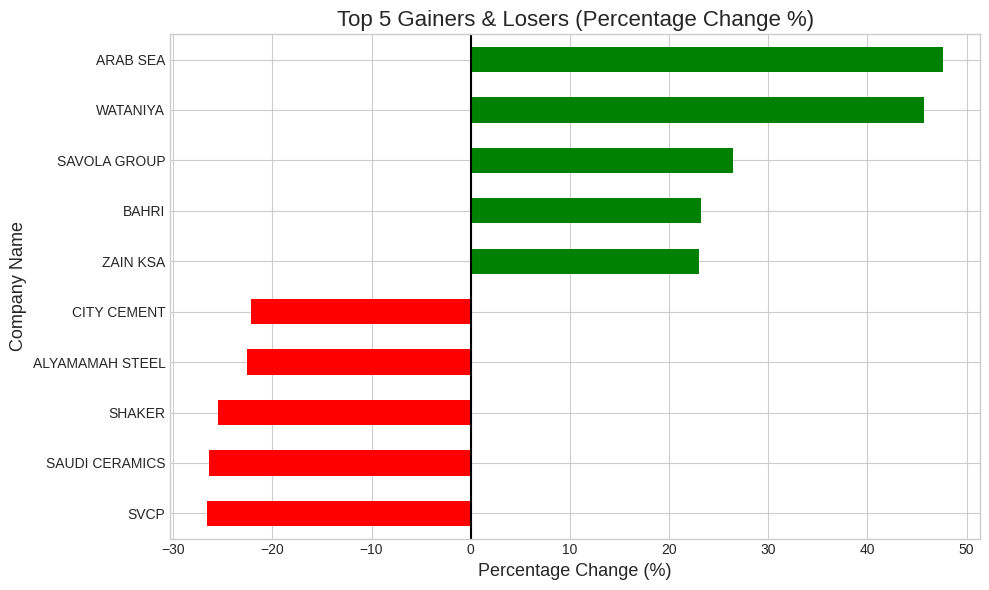

In [124]:
# sorting data by date
data = data.sort_values(by="date")

# first and last close price for every company
first_close = data.groupby("trading_name")["close"].first()
last_close = data.groupby("trading_name")["close"].last()

# calculating percentage change
perc_change = ((last_close - first_close) / first_close) * 100

# best 5 companies
top_5_gainers = perc_change.nlargest(5)
top_5_losers = perc_change.nsmallest(5)

extreme_performers = pd.concat([top_5_gainers, top_5_losers]).sort_values()

plt.figure(figsize=(10,6))

colors = ['red' if x < 0 else 'green' for x in extreme_performers.values]

extreme_performers.plot(kind='barh', color=colors)

plt.title("Top 5 Gainers & Losers (Percentage Change %)")
plt.xlabel("Percentage Change (%)")
plt.ylabel("Company Name")

plt.axvline(0, color='black')

plt.tight_layout()
plt.show()

### Insight

The chart highlights the best and worst performing companies based on percentage price change over the analyzed period.

Arab Sea and Wataniya recorded the highest gains, indicating strong positive performance.
On the other hand, companies such as SVCP and Saudi Ceramics experienced the largest declines.

This contrast reflects the varying performance levels across companies in the market.

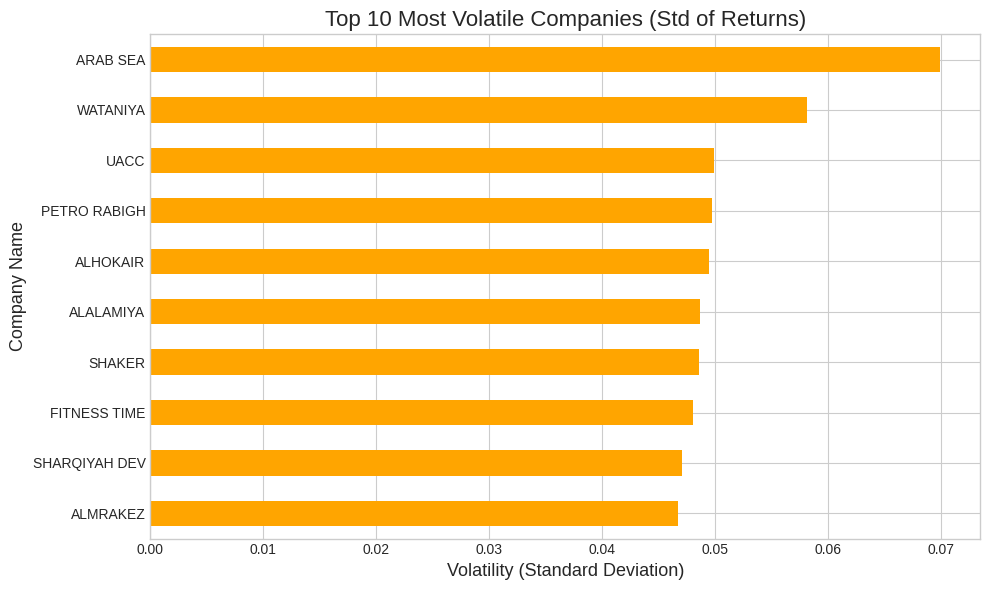

In [125]:
# calclut the returning
data["daily_return"] = data.groupby(["trading_name"])["close"].pct_change()

volatility = data.groupby(["trading_name"])["daily_return"].std().nlargest(10).sort_values()


plt.figure(figsize=(10,6))

volatility.plot(kind="barh", color="orange")

plt.title("Top 10 Most Volatile Companies (Std of Returns)")
plt.xlabel("Volatility (Standard Deviation)")
plt.ylabel("Company Name")

plt.tight_layout()
plt.show()

### Insight

The chart identifies companies with the highest price volatility.

Arab Sea and Wataniya appear among the most volatile stocks, indicating larger fluctuations in daily returns.
Higher volatility often reflects increased market uncertainty or stronger trading activity.

Such stocks may present higher risk but also potential opportunities for traders.

/tmp/ipykernel_288/2640885805.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=daily_volume.index, y=daily_volume.values, palette="viridis")


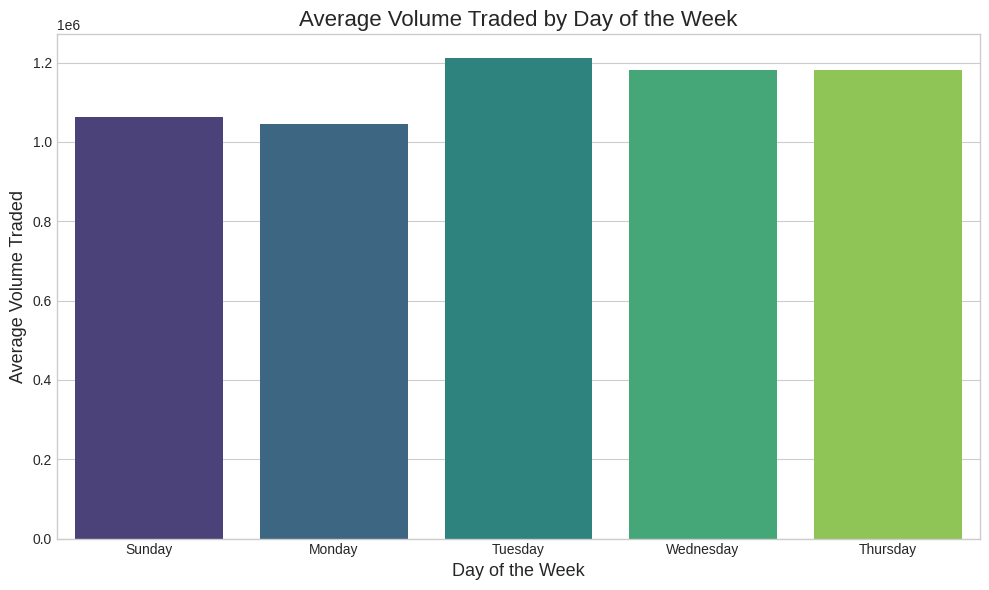

In [126]:
data["day_name"] = data["date"].dt.day_name()

days_order = ["Sunday","Monday","Tuesday","Wednesday","Thursday"]

daily_volume = data.groupby(["day_name"])["volume_traded"].mean().reindex(days_order)



plt.figure(figsize=(10,6))

sns.barplot(x=daily_volume.index, y=daily_volume.values, palette="viridis")

plt.title("Average Volume Traded by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Volume Traded")

plt.tight_layout()
plt.show()

### Insight

The chart shows how trading activity varies across the week.

Tuesday appears to have the highest average trading volume, suggesting stronger market participation on that day.
Monday shows slightly lower activity, while the rest of the week maintains relatively similar trading levels.

## Skills Demonstrated

This project demonstrates several key data analysis skills:

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualization
- Financial Data Analysis
- Correlation Analysis
- Python for Data Analysis (Pandas, NumPy)

## Market Feature Correlation Analysis

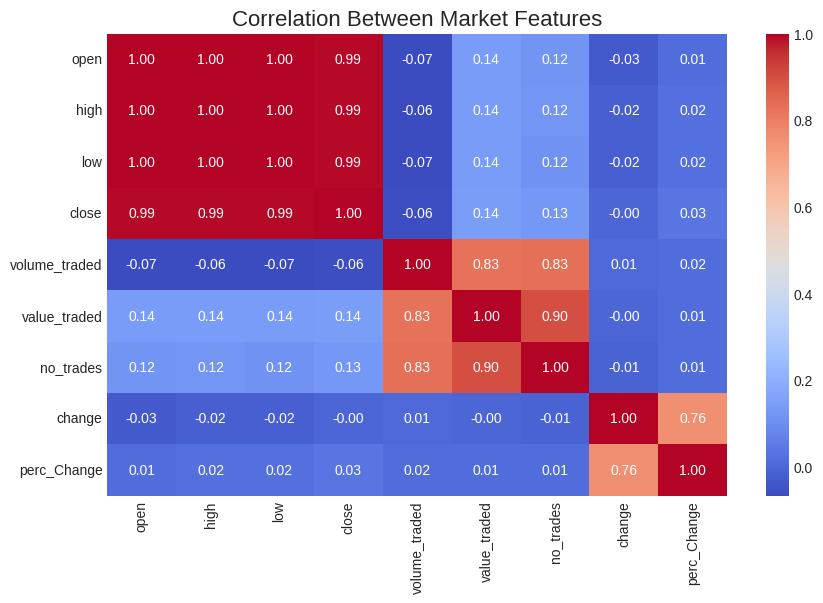

In [127]:
plt.figure(figsize=(10,6))

corr = data[['open','high','low','close','volume_traded','value_traded','no_trades','change','perc_Change']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Market Features")
plt.show()

### Insight

The correlation heatmap reveals several strong relationships between market variables.

First, there is an extremely strong correlation between open, high, low, and close prices (close to 1.0). This is expected since these variables represent different price levels of the same stock during a trading session.

Second, trading activity variables such as volume_traded, value_traded, and no_trades show strong positive correlations with each other. This indicates that when trading volume increases, both the total value of trades and the number of trades also tend to increase.

Finally, change and perc_change are also strongly correlated (0.76), which makes sense because percentage change is derived from price change.

Overall, the heatmap confirms logical relationships between price variables and trading activity in the market.

Another observation is that trading activity variables show weak correlation with price levels, suggesting that trading volume does not necessarily depend on the absolute stock price.

In [131]:
data.to_csv("saudi_stock_cleand.csv", index=False)

## Key Findings

Several important insights were discovered during this analysis:

- Price variables such as open, high, low, and close show extremely strong correlations, which is expected since they represent different price levels during the same trading session.

- Trading activity indicators (volume_traded, value_traded, and number of trades) are strongly correlated, suggesting that increased market participation leads to higher liquidity.

- The Financials sector dominates the market in both number of companies and trading activity.

- Some companies exhibit significantly higher volatility than others, indicating higher risk and stronger price fluctuations.

- Most daily price changes are relatively small and concentrated around zero, while extreme price movements occur less frequently.

These findings highlight the structural characteristics of the Saudi stock market and demonstrate how exploratory data analysis can reveal patterns in financial datasets.

## Conclusion

This analysis explored stock market behavior using multiple perspectives including price distribution, sector performance, company performance, volatility, and trading activity.

The results show that price variables (open, high, low, close) are strongly correlated, which is expected since they represent different price levels during the same trading session.

Trading activity indicators such as volume traded, value traded, and number of trades also show strong relationships, suggesting that increased trading participation leads to higher market liquidity.

Additionally, some companies exhibit significantly higher volatility and price changes compared to others, indicating different risk levels across the market.

Overall, this analysis provides insights into stock performance patterns and trading behavior within the Saudi market.

This analysis demonstrates how exploratory data analysis can be used to uncover meaningful insights from financial market data.